# Automated annotation: CellAssign

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
import torch
from scvi.external import CellAssign

/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/opt

In [2]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.2.0


In [3]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
#save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [4]:
l1 = sc.read('L1_annotation.h5ad')
l2 = sc.read('L2_annotation.h5ad')

celltype_markers = pd.read_csv('/home/sources/atlases/shortlist.tsv', sep='\t', skiprows=0)
celltype_markers = celltype_markers[~celltype_markers['Cell type'].isna()]
celltype_markers = celltype_markers[['TAIR', 'Cell type']].drop_duplicates()
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'cambium']
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'sieve element']

celltype_markers = celltype_markers.set_index('TAIR')
celltype_markers = celltype_markers.pivot(columns='Cell type', values='Cell type')
celltype_markers[~celltype_markers.isna()] = 1
celltype_markers[celltype_markers.isna()] = 0
celltype_markers['unknown'] = 0
celltype_markers = celltype_markers.astype(int)

l1.obs.index = l1.obs.index.astype("str")
l1.var.index = l1.var.index.astype("str")
l1.var_names_make_unique()
l1.obs_names_make_unique()

l2.obs.index = l2.obs.index.astype("str")
l2.var.index = l2.var.index.astype("str")
l2.var_names_make_unique()
l2.obs_names_make_unique()

l1

AnnData object with n_obs × n_vars = 4238 × 16110
    obs: 'n_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_cp', 'log1p_total_counts_cp', 'pct_counts_cp', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'cp_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'manual_celltype_annotation'
    var: 'gene_ids', 'mt', 'cp', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'manual_celltype_annotation_colors', 'n

In [5]:
celltype_markers

Cell type,S phase,companion cell,epidermis,mesophyll,proliferating cell,vasculature,xylem,unknown
TAIR,,,,,,,,
AT1G07370,1,0,0,0,0,0,0,0
AT1G09310,0,0,1,0,0,0,0,0
AT1G12090,0,0,0,1,0,0,0,0
AT1G25275,0,0,1,0,0,0,0,0
AT1G27950,0,0,1,0,0,0,0,0
AT1G29670,0,0,1,0,0,0,0,0
AT1G56580,0,0,1,0,0,0,0,0
AT1G61660,0,0,0,0,0,1,0,0
AT2G27385,0,0,1,0,0,0,0,0


In [6]:
shared_genes_l1 = l1.var_names.intersection(celltype_markers.index)
shared_genes_l2 = l2.var_names.intersection(celltype_markers.index)

In [7]:
l1_bdata = l1[:, shared_genes_l1].copy()
l2_bdata = l2[:, shared_genes_l2].copy()

## L1 

In [8]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='counts', size_factor_key="size_factors")

/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [9]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 3/400:   0%|          | 2/400 [00:00<01:44,  3.81it/s, v_num=1, train_loss_step=28.7, train_loss_epoch=29.1]

Epoch 400/400: 100%|██████████| 400/400 [01:25<00:00,  4.83it/s, v_num=1, train_loss_step=7.15, train_loss_epoch=7.37]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:25<00:00,  4.69it/s, v_num=1, train_loss_step=7.15, train_loss_epoch=7.37]


<Axes: xlabel='epoch'>

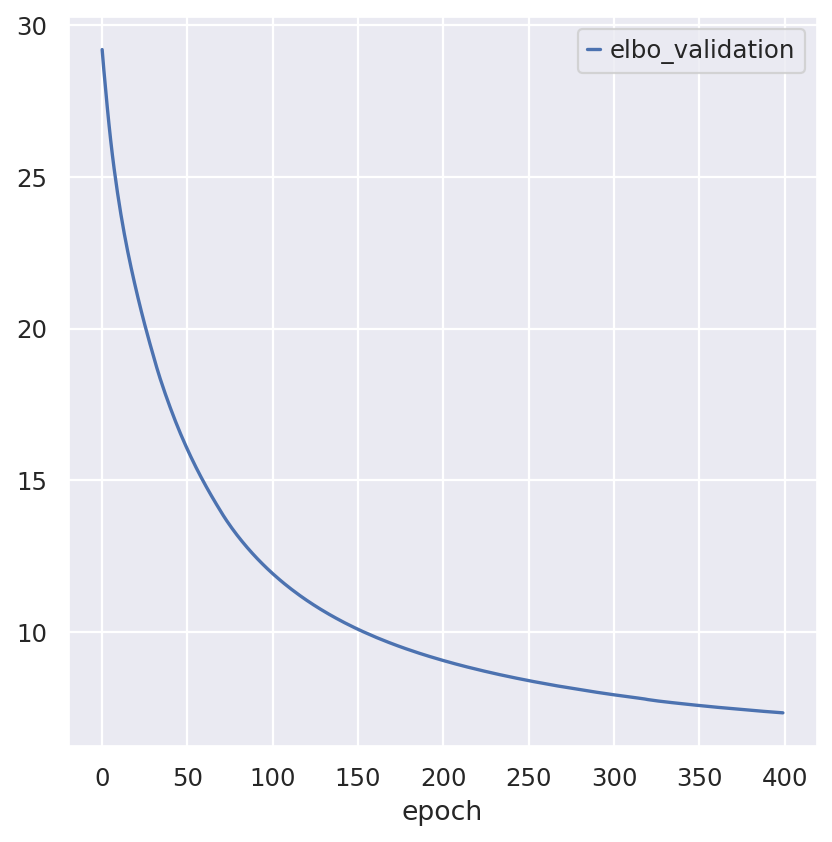

In [10]:
l1_model.history["elbo_validation"].plot()

In [11]:
predictions = l1_model.predict()
predictions.head()

Cell type,S phase,companion cell,epidermis,mesophyll,proliferating cell,vasculature,xylem,unknown
0,8.140298e-05,0.077565,9.185130e-01,0.000009,0.000417,4.717120e-04,0.000739,0.002204
1,1.309244e-04,0.076096,9.202188e-01,0.000025,0.000460,1.561909e-21,0.000816,0.002253
2,8.081533e-05,0.077312,9.192494e-01,0.000009,0.000416,6.289357e-22,0.000737,0.002196
3,1.538815e-12,0.958178,2.082416e-09,0.000313,0.005151,4.639966e-21,0.009122,0.027236
4,3.283585e-04,0.079695,9.158494e-01,0.000056,0.000594,3.117843e-13,0.001057,0.002420


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


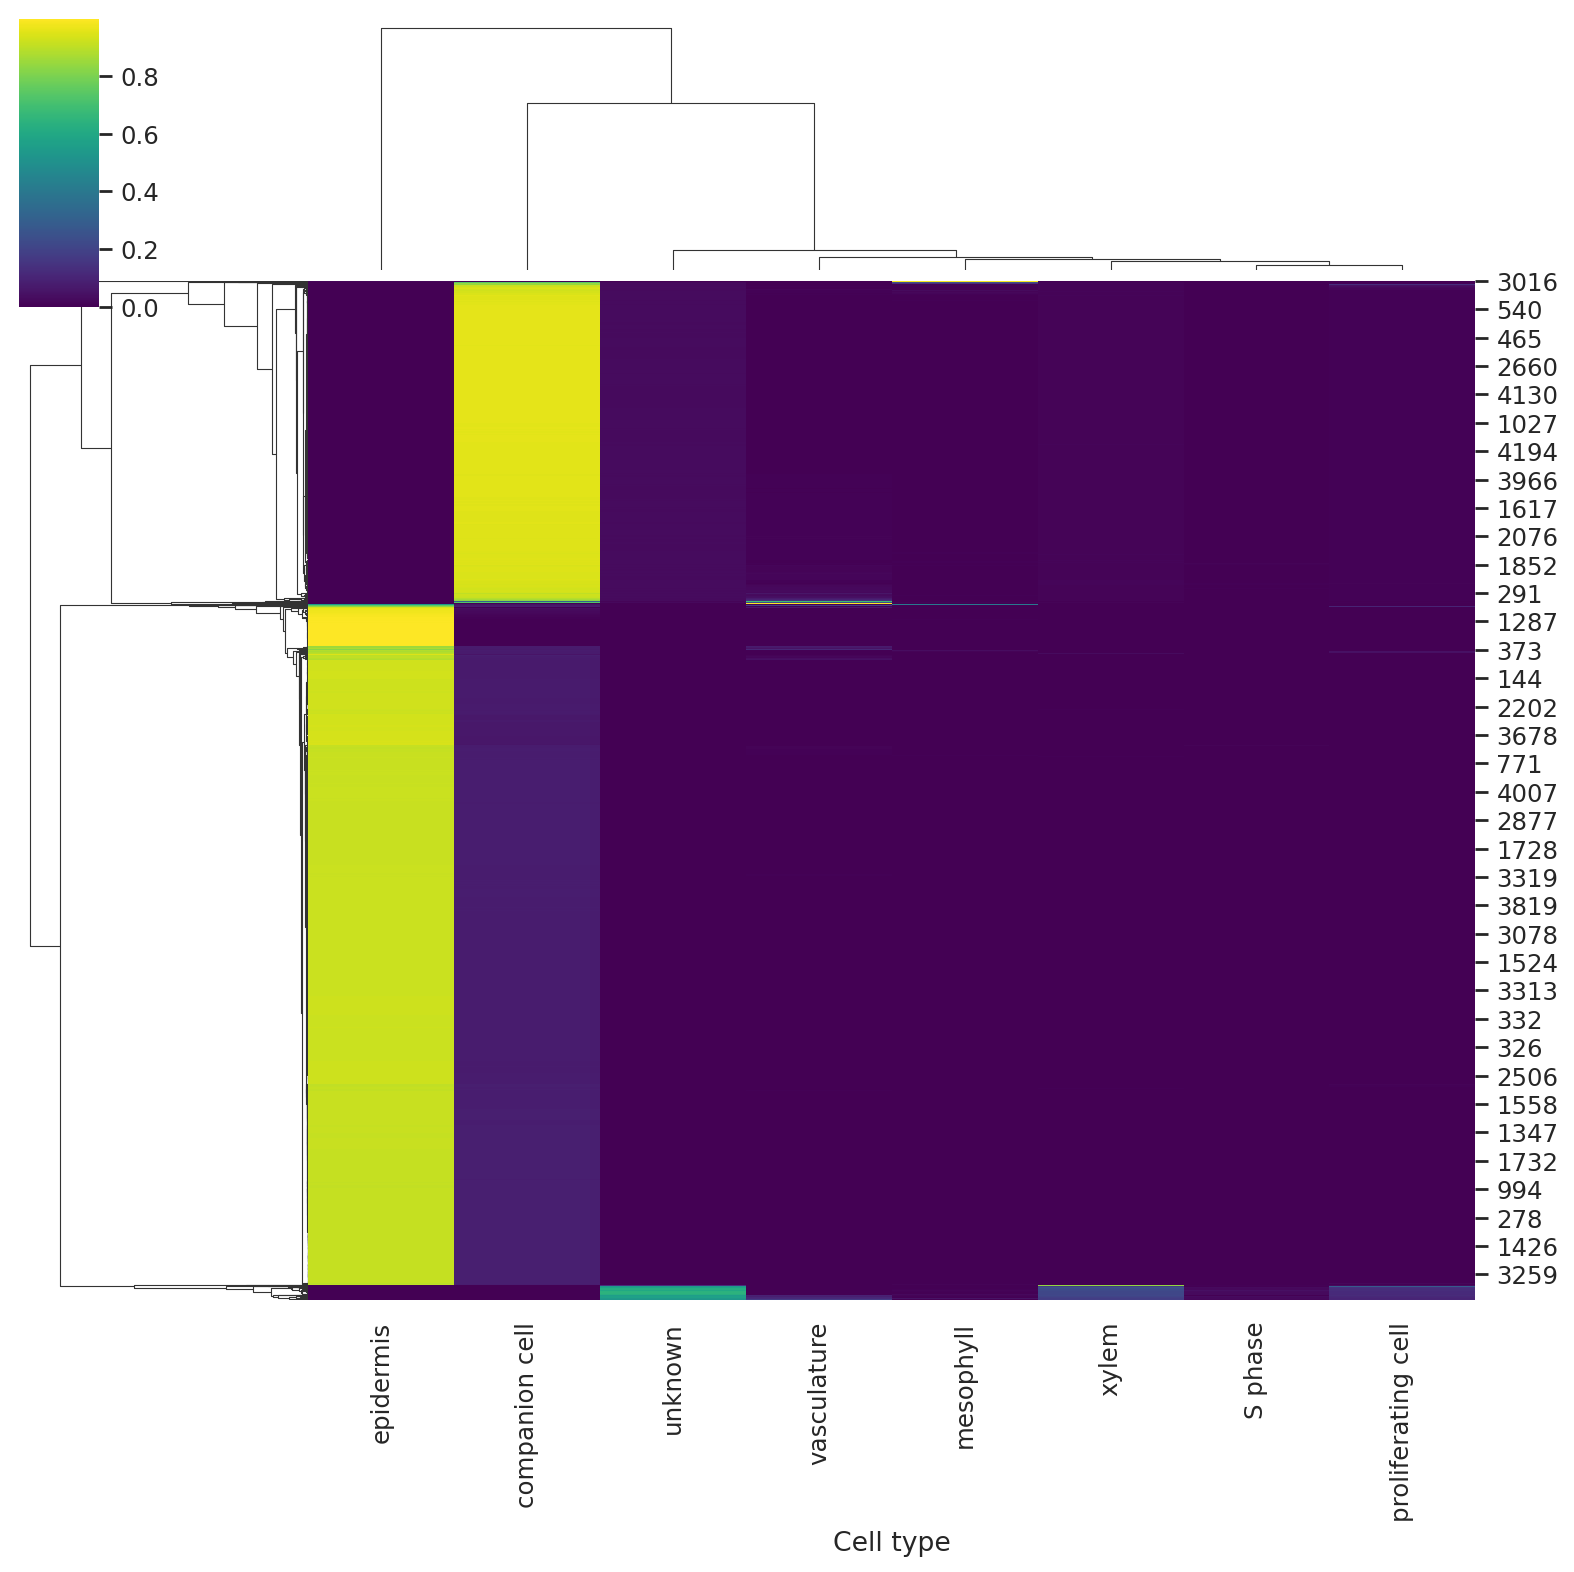

In [12]:
sns.clustermap(predictions, cmap="viridis")

In [13]:
l1_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

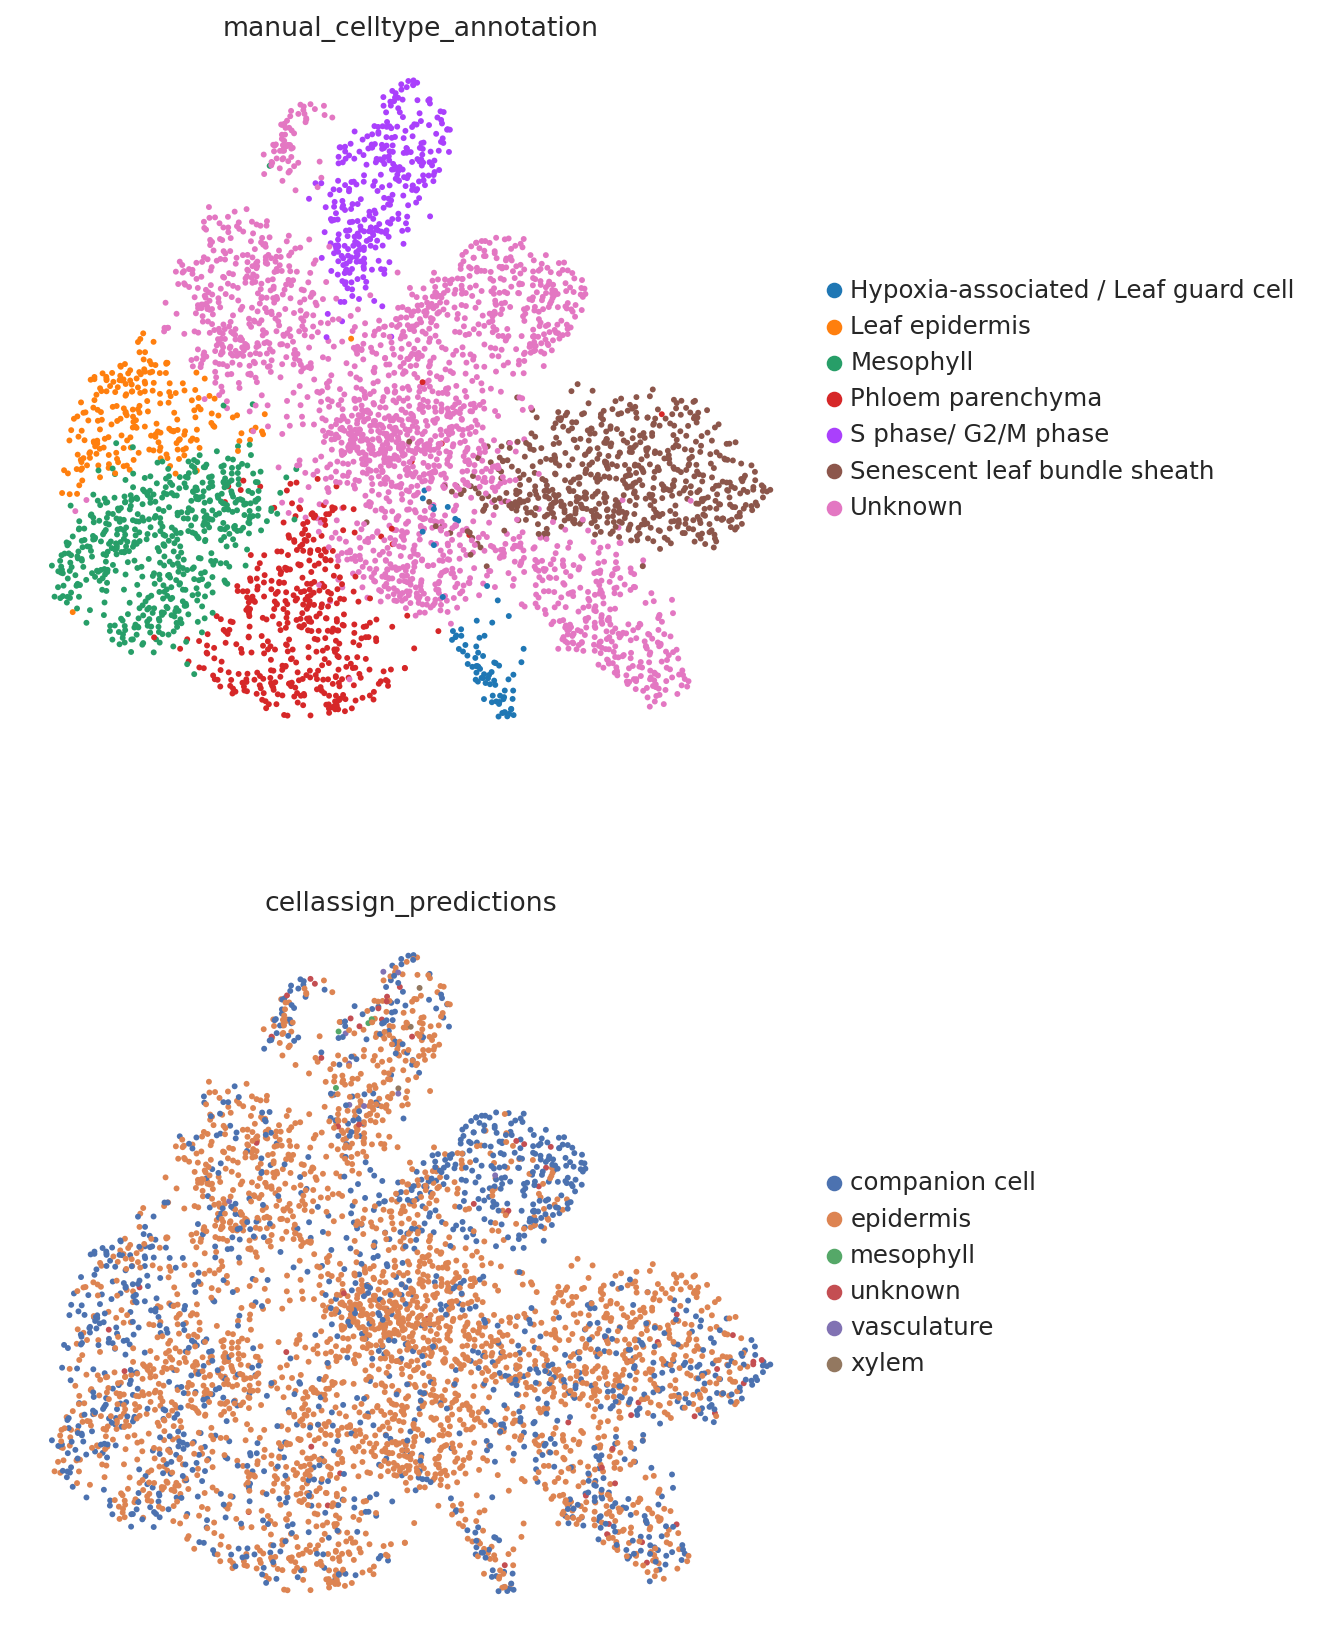

In [14]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L2

In [15]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='counts', size_factor_key="size_factors")

/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [16]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 3/400:   0%|          | 2/400 [00:00<00:55,  7.16it/s, v_num=1, train_loss_step=27.9, train_loss_epoch=27.6]

Epoch 400/400: 100%|██████████| 400/400 [00:56<00:00,  6.04it/s, v_num=1, train_loss_step=9.31, train_loss_epoch=9.64]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [00:56<00:00,  7.05it/s, v_num=1, train_loss_step=9.31, train_loss_epoch=9.64]


<Axes: xlabel='epoch'>

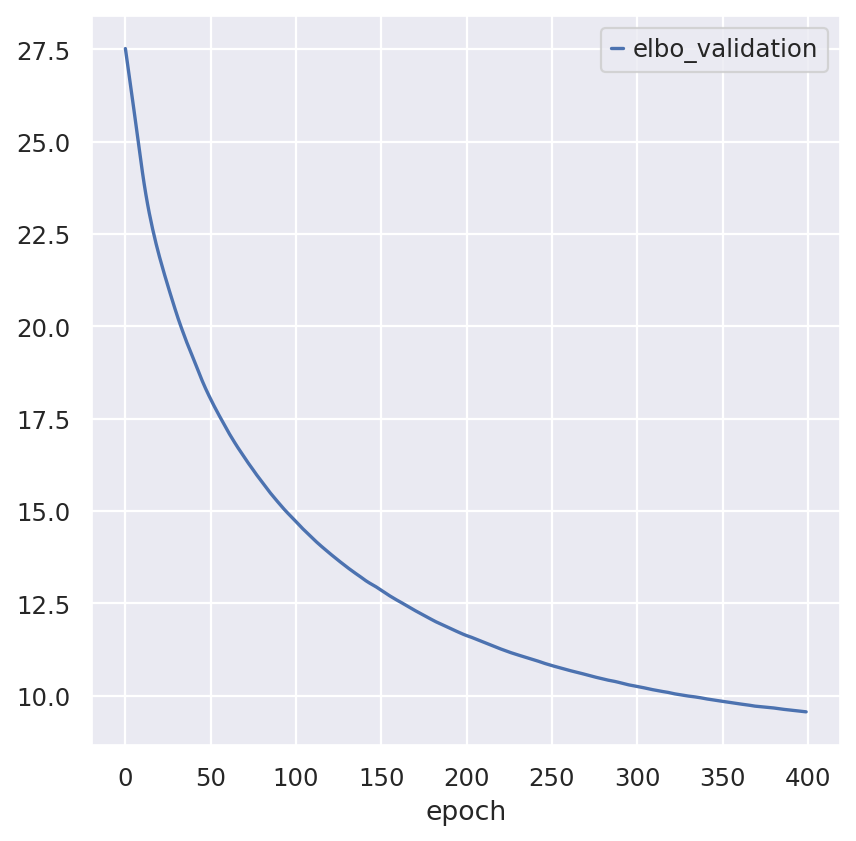

In [17]:
l2_model.history["elbo_validation"].plot()

In [18]:
predictions = l2_model.predict()
predictions.head()

Cell type,S phase,companion cell,epidermis,mesophyll,proliferating cell,vasculature,xylem,unknown
0,6.611530e-03,0.000109,9.059825e-15,0.974275,0.000086,1.390700e-02,0.000286,0.004726
1,6.057452e-03,0.000096,5.306249e-15,0.989296,0.000076,3.404276e-31,0.000251,0.004223
2,6.159630e-03,0.000099,6.327731e-14,0.989045,0.000078,2.995381e-12,0.000260,0.004358
3,6.185130e-03,0.000100,1.107657e-05,0.988980,0.000079,5.282259e-22,0.000262,0.004383
4,2.718196e-12,0.000097,3.932560e-15,0.995343,0.000076,4.230569e-12,0.000255,0.004229


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


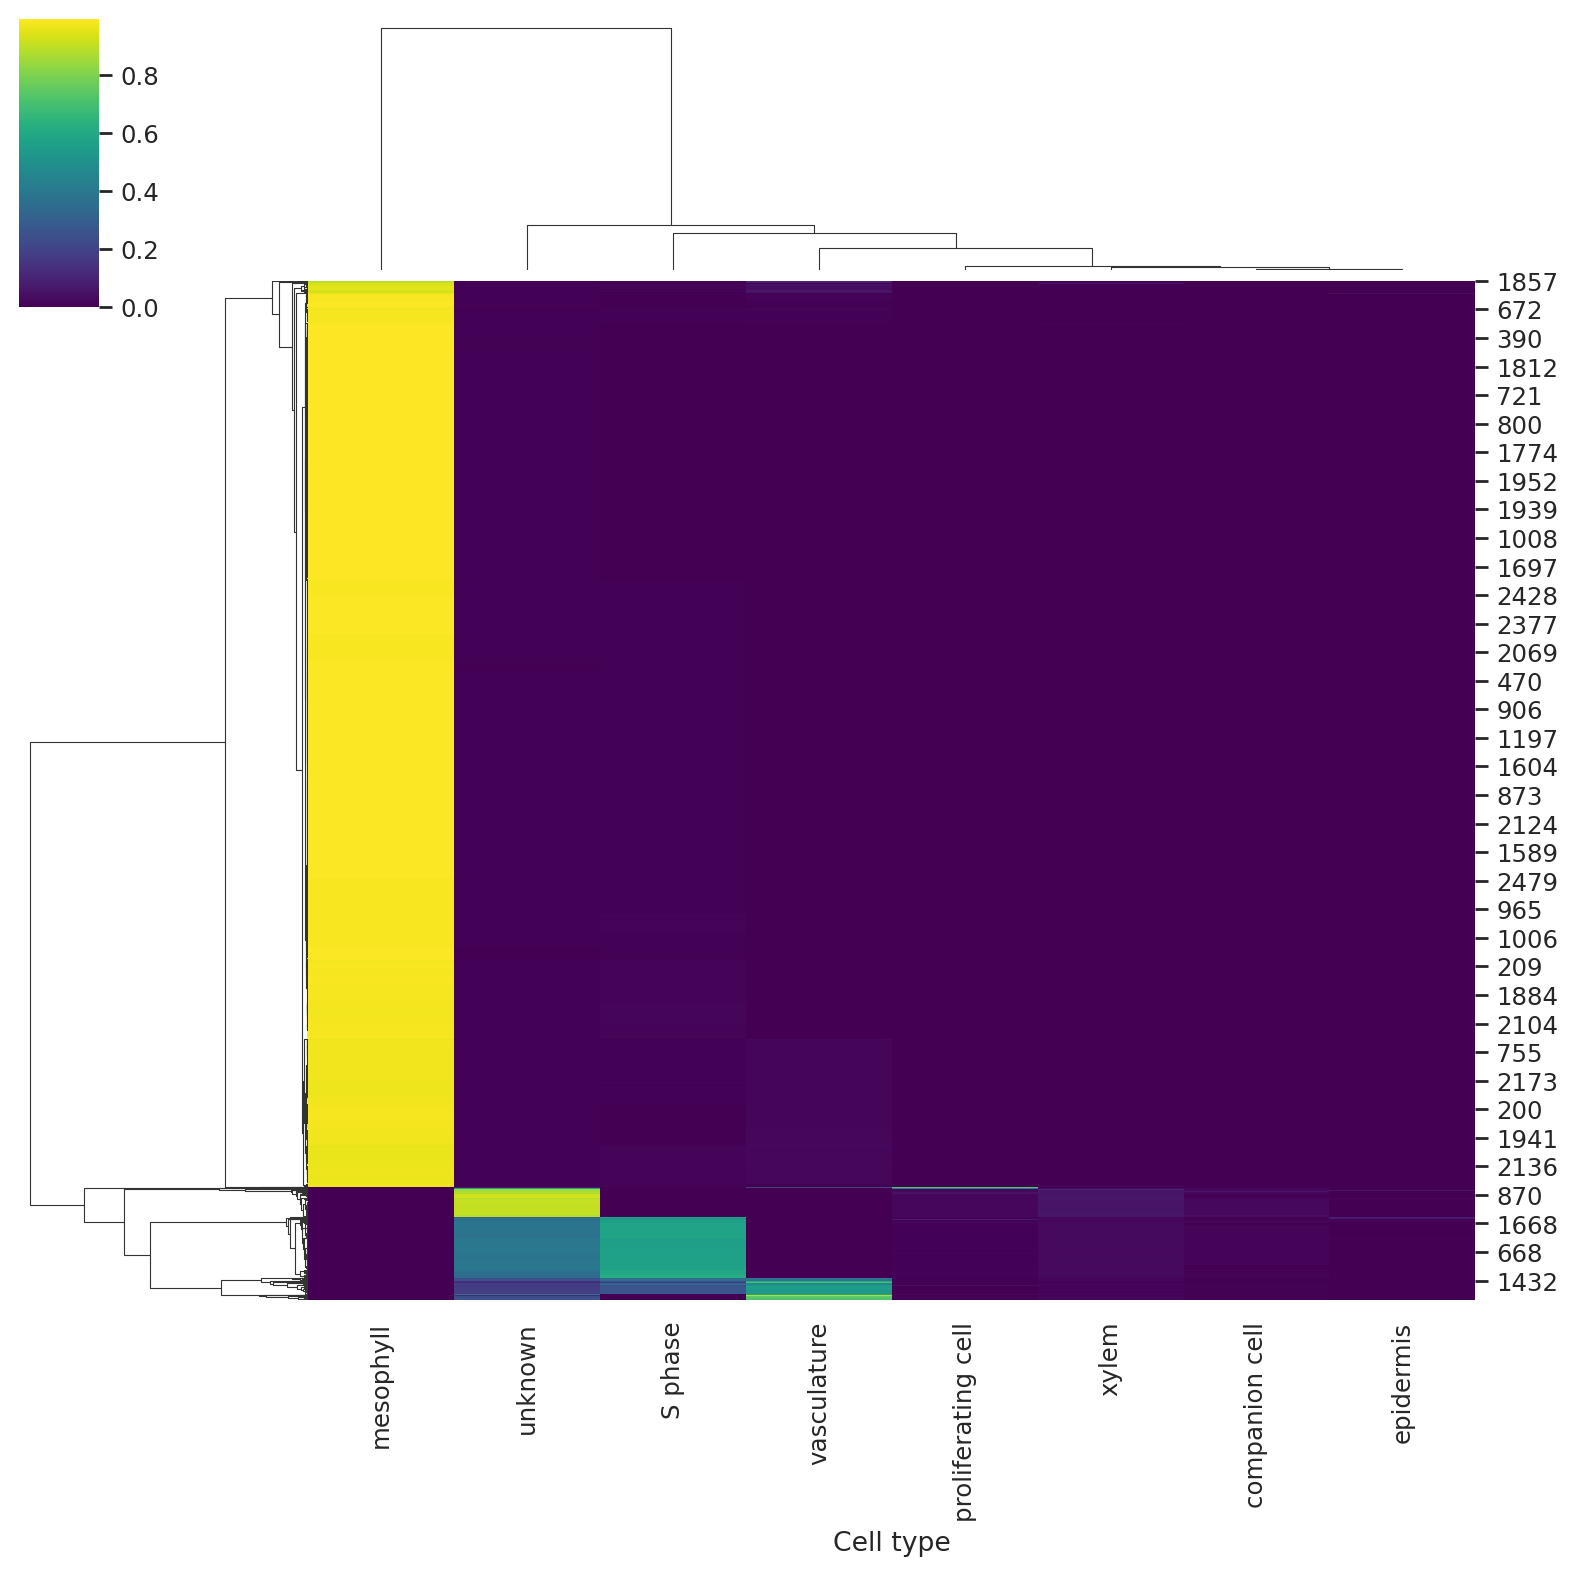

In [19]:
sns.clustermap(predictions, cmap="viridis")

In [20]:
l2_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

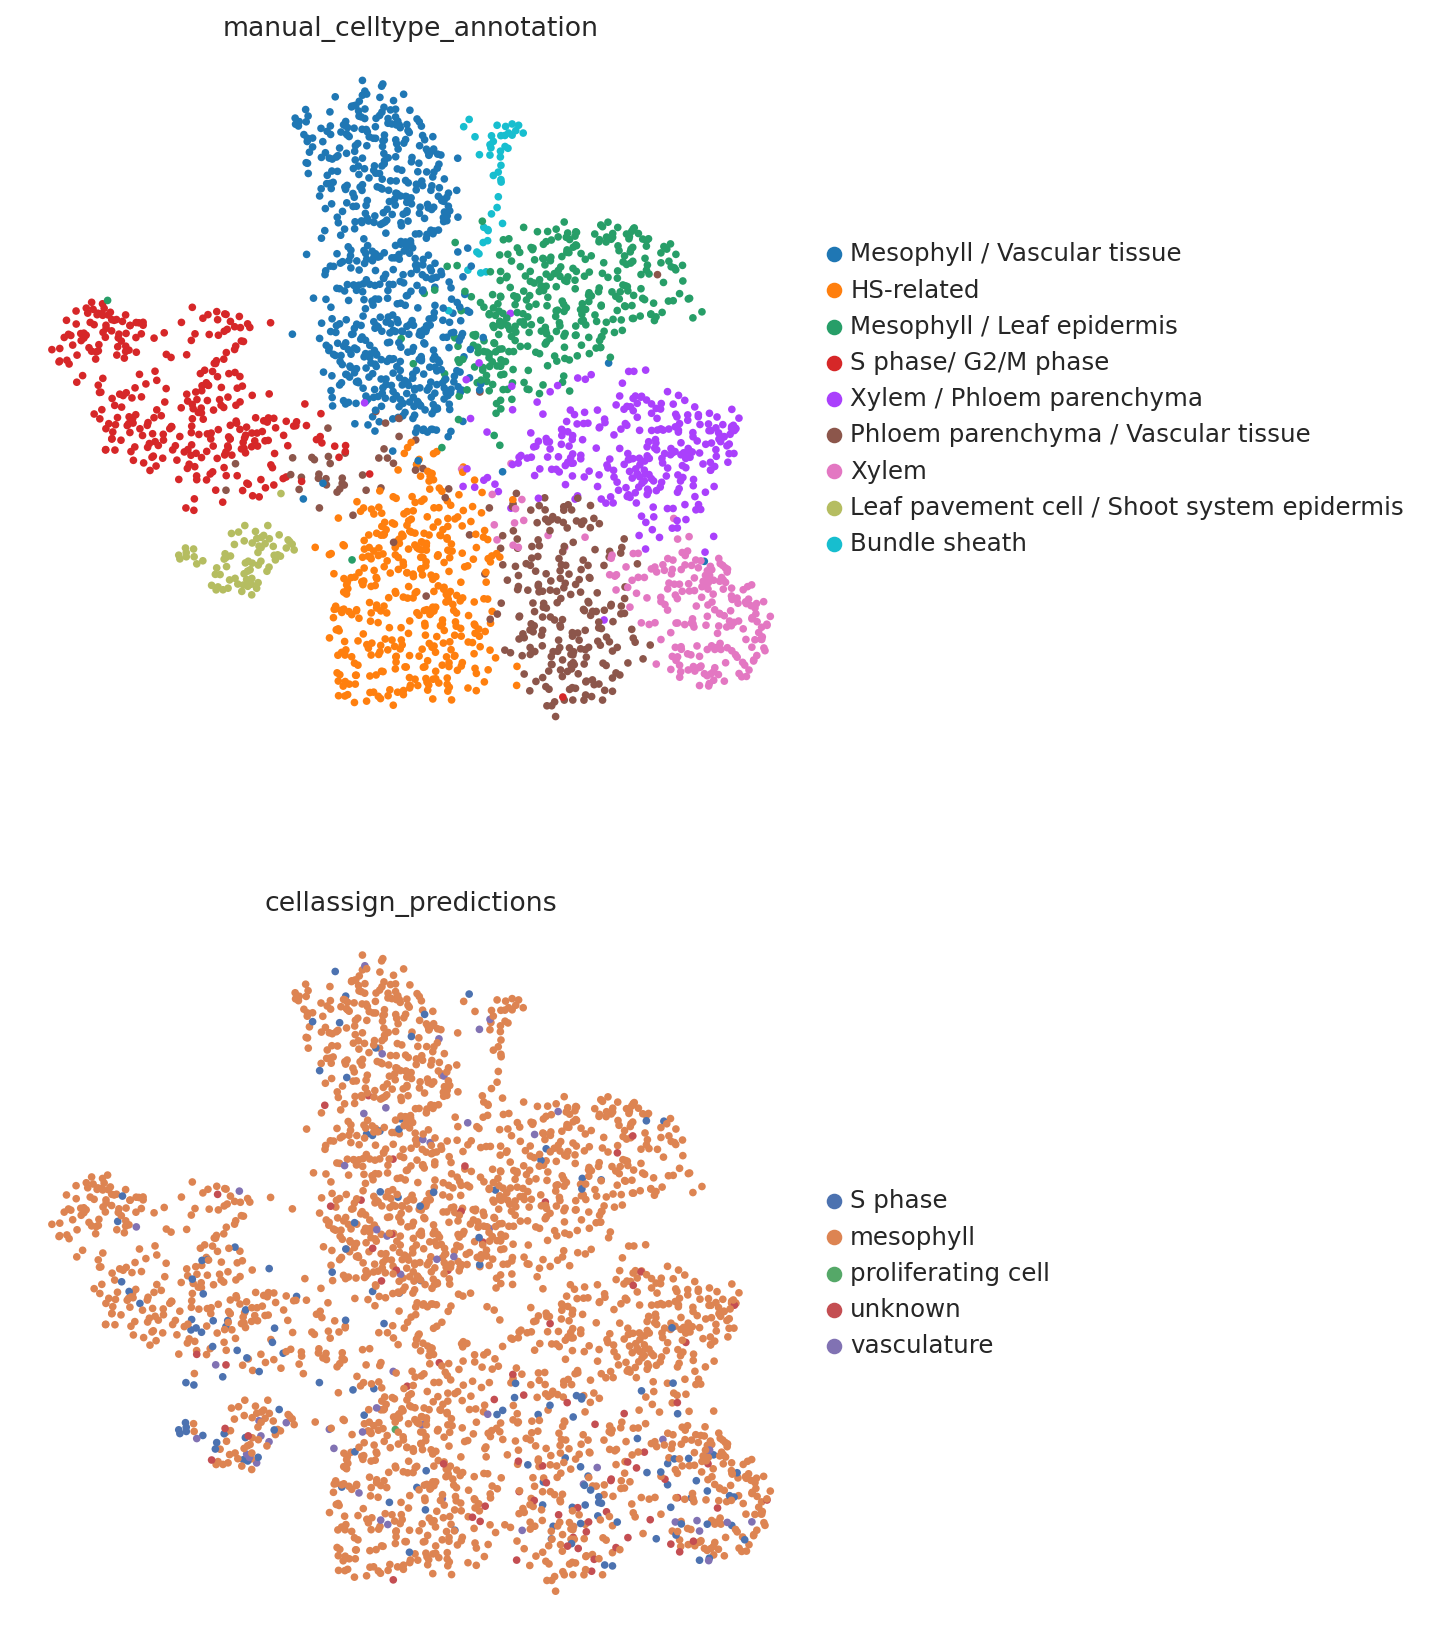

In [21]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L1 on SoupX layer

In [22]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [23]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 2/400:   0%|          | 1/400 [00:00<01:23,  4.75it/s, v_num=1, train_loss_step=37, train_loss_epoch=37.2]

Epoch 400/400: 100%|██████████| 400/400 [01:27<00:00,  3.87it/s, v_num=1, train_loss_step=10.1, train_loss_epoch=9.47]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:27<00:00,  4.57it/s, v_num=1, train_loss_step=10.1, train_loss_epoch=9.47]


<Axes: xlabel='epoch'>

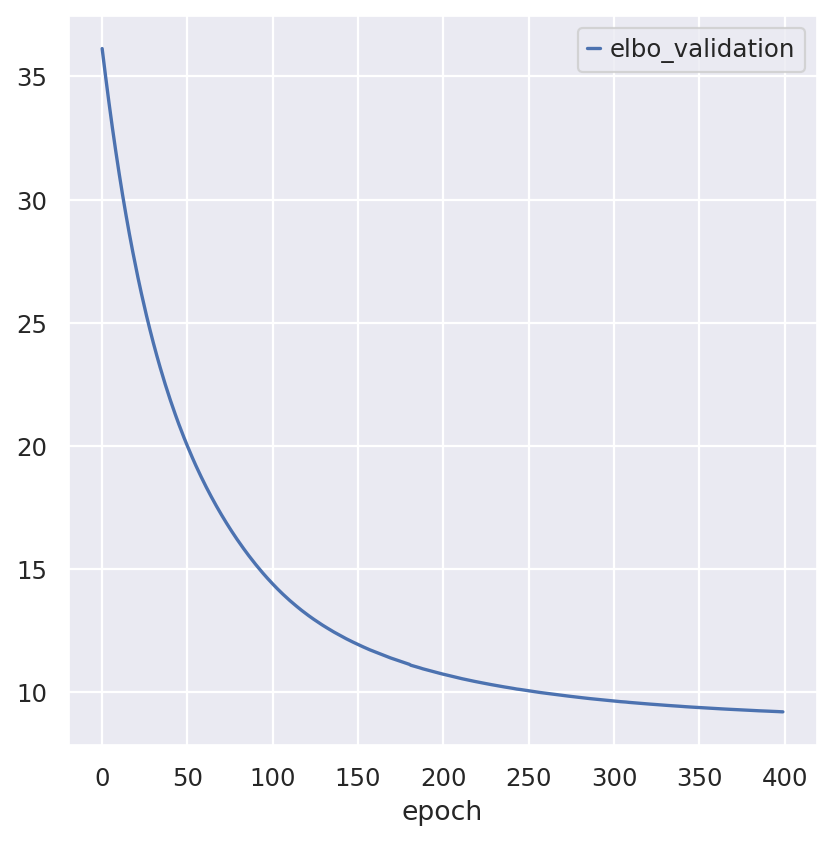

In [24]:
l1_model.history["elbo_validation"].plot()

In [25]:
predictions = l1_model.predict()
predictions.head()

Cell type,S phase,companion cell,epidermis,mesophyll,proliferating cell,vasculature,xylem,unknown
0,0.000038,0.000006,1.565069e-04,0.000279,5.341051e-07,0.000116,0.000001,0.999403
1,0.000273,0.000003,6.271016e-06,0.000494,1.492819e-06,0.000353,0.000007,0.998862
2,0.000037,0.000006,1.560138e-04,0.000275,5.355099e-07,0.005533,0.000001,0.993990
3,0.000247,0.000006,4.254540e-04,0.001136,5.295508e-07,0.000871,0.000001,0.997312
4,0.000695,0.000012,9.886526e-08,0.000724,9.375310e-06,0.000001,0.000045,0.998513


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


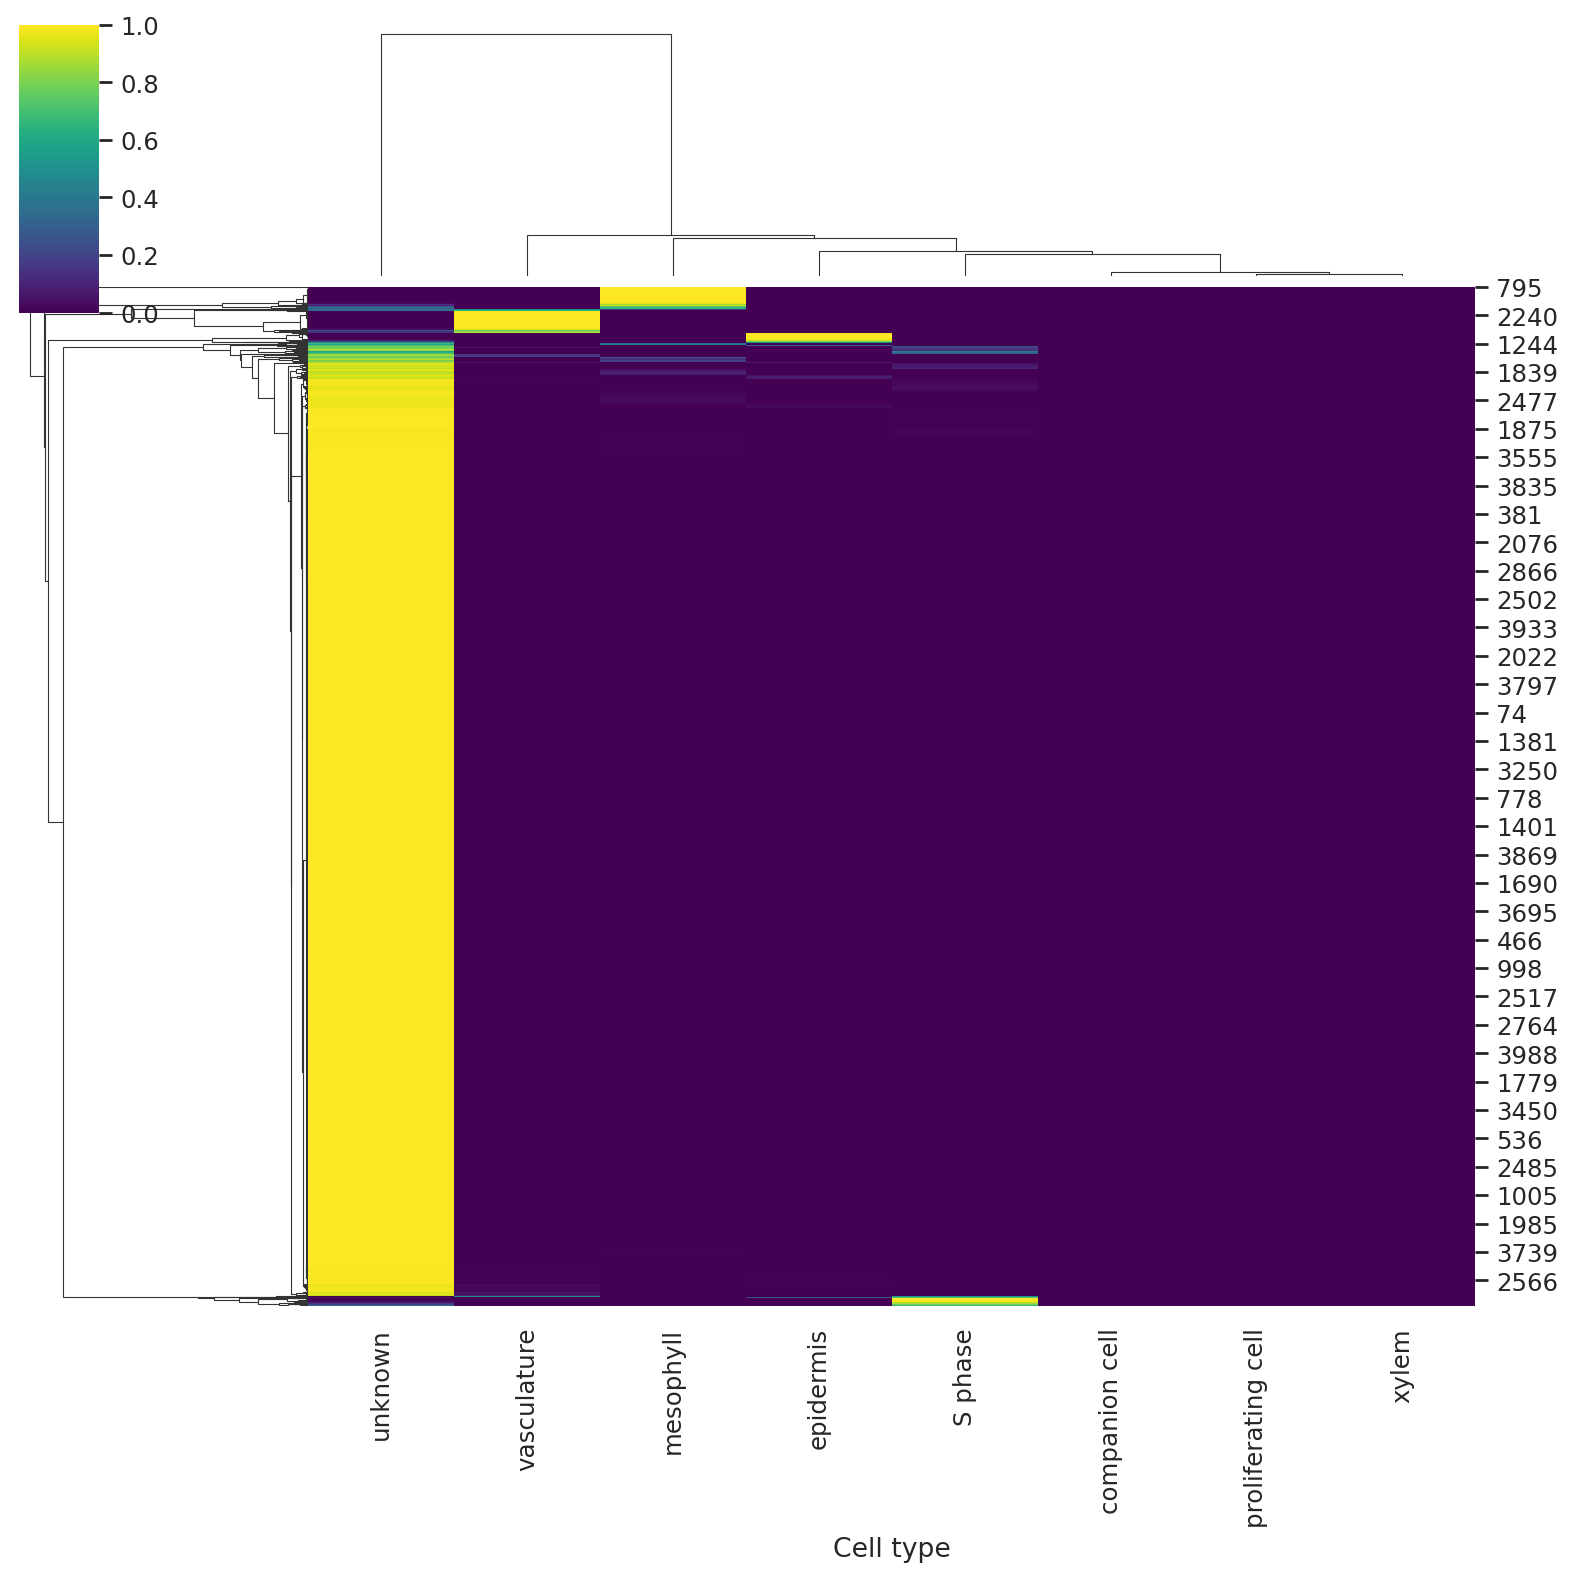

In [26]:
sns.clustermap(predictions, cmap="viridis")

In [27]:
l1_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

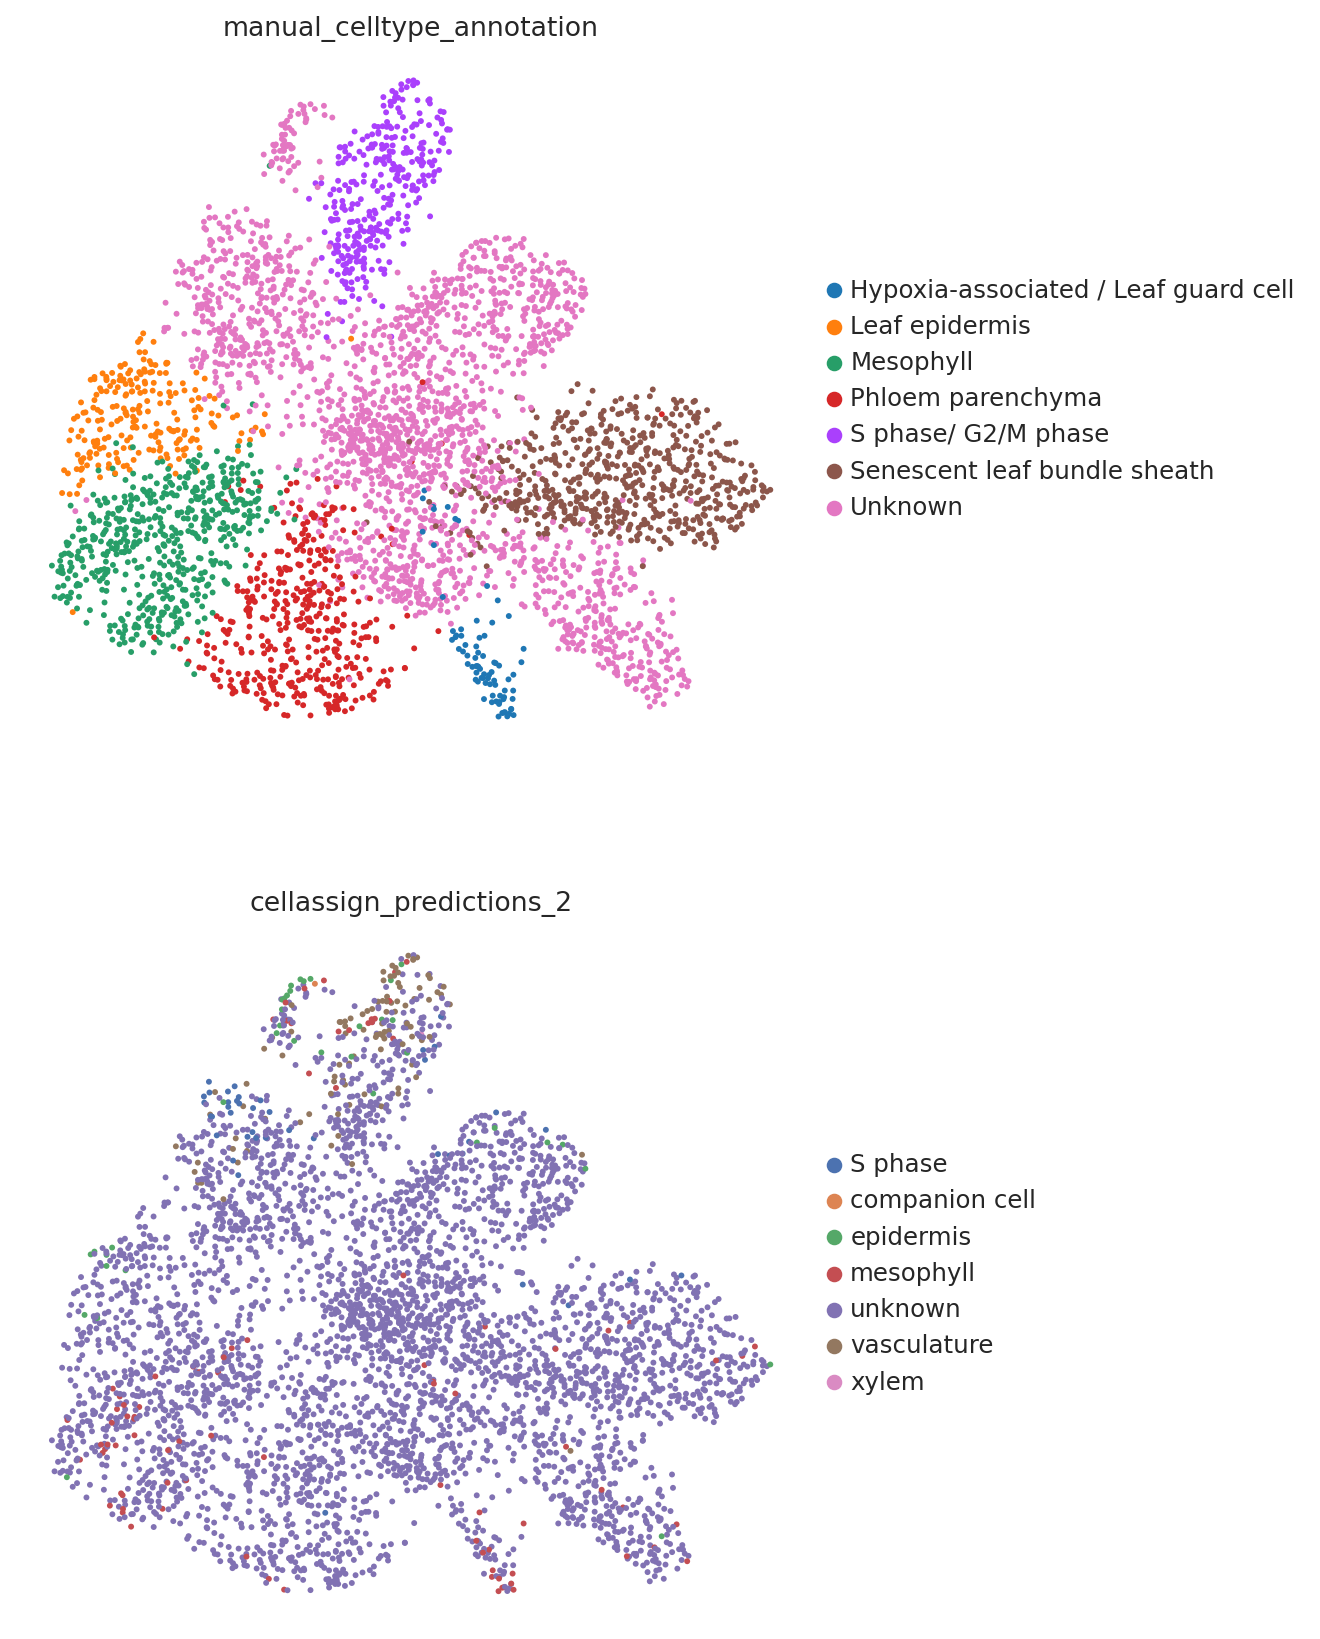

In [28]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

## L2 on SoupX layer

In [29]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [30]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 2/400:   0%|          | 1/400 [00:00<00:56,  7.05it/s, v_num=1, train_loss_step=35.4, train_loss_epoch=35.8]

Epoch 400/400: 100%|██████████| 400/400 [00:57<00:00,  6.98it/s, v_num=1, train_loss_step=12.5, train_loss_epoch=12.7]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [00:57<00:00,  6.93it/s, v_num=1, train_loss_step=12.5, train_loss_epoch=12.7]


<Axes: xlabel='epoch'>

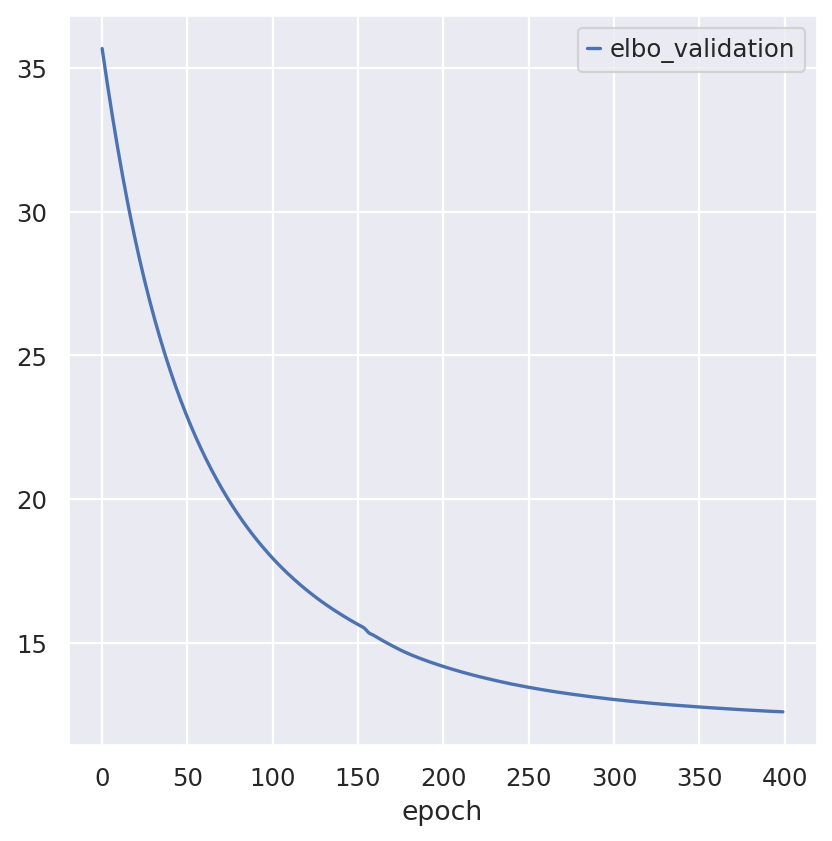

In [31]:
l2_model.history["elbo_validation"].plot()

In [32]:
predictions = l2_model.predict()
predictions.head()

Cell type,S phase,companion cell,epidermis,mesophyll,proliferating cell,vasculature,xylem,unknown
0,0.000064,0.000045,0.000216,0.000329,0.000076,0.000146,0.000252,0.998872
1,0.000032,0.000028,0.000208,0.000244,0.000039,0.072939,0.000183,0.926326
2,0.000044,0.000035,0.024777,0.000280,0.000052,0.000253,0.000213,0.974347
3,0.000046,0.000037,0.000117,0.000290,0.000055,0.000898,0.000221,0.998337
4,0.006381,0.000023,0.000252,0.000229,0.000028,0.000142,0.000166,0.992779


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


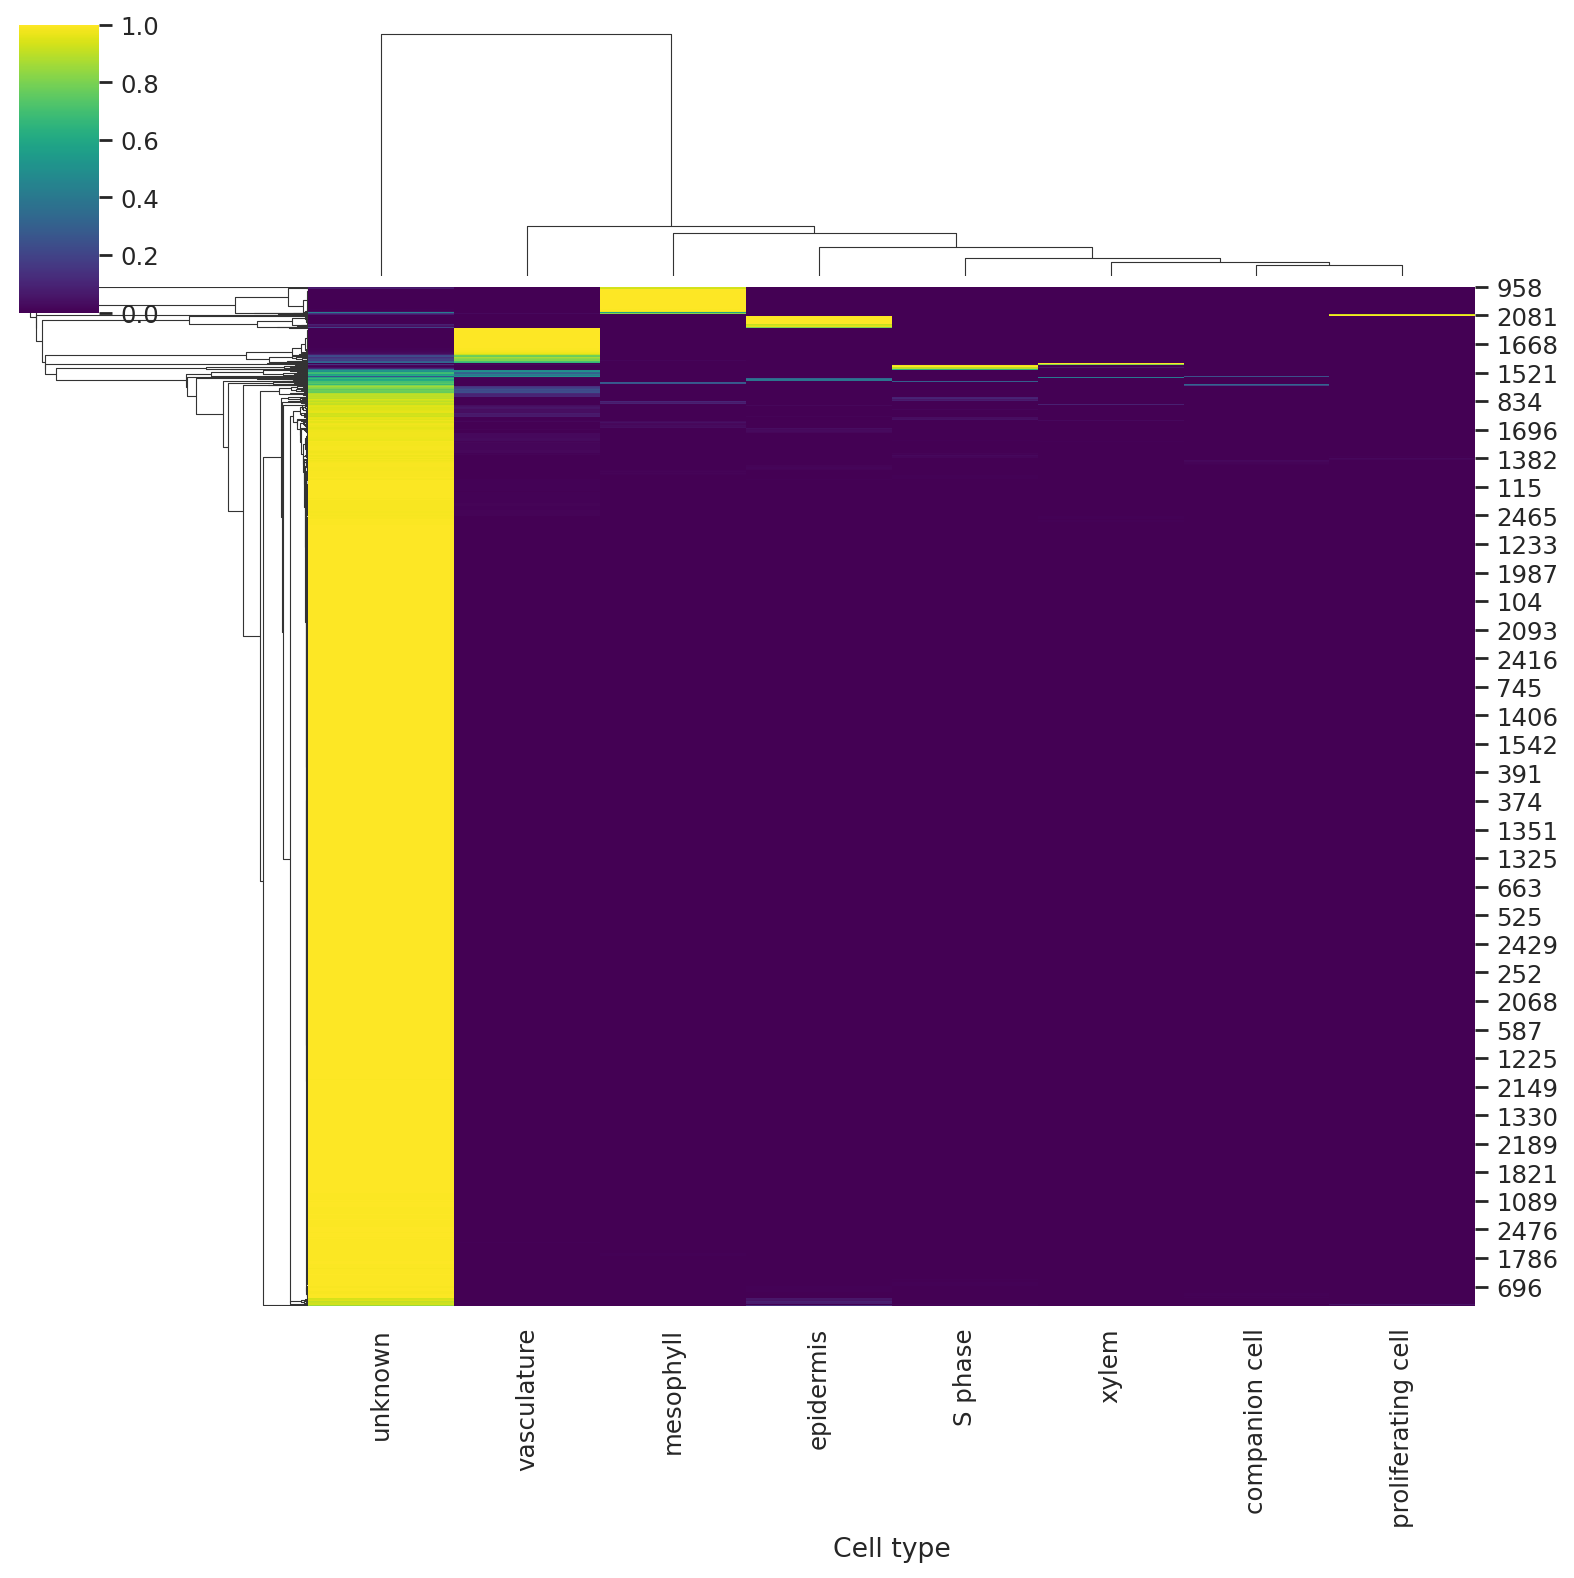

In [33]:
sns.clustermap(predictions, cmap="viridis")

In [34]:
l2_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

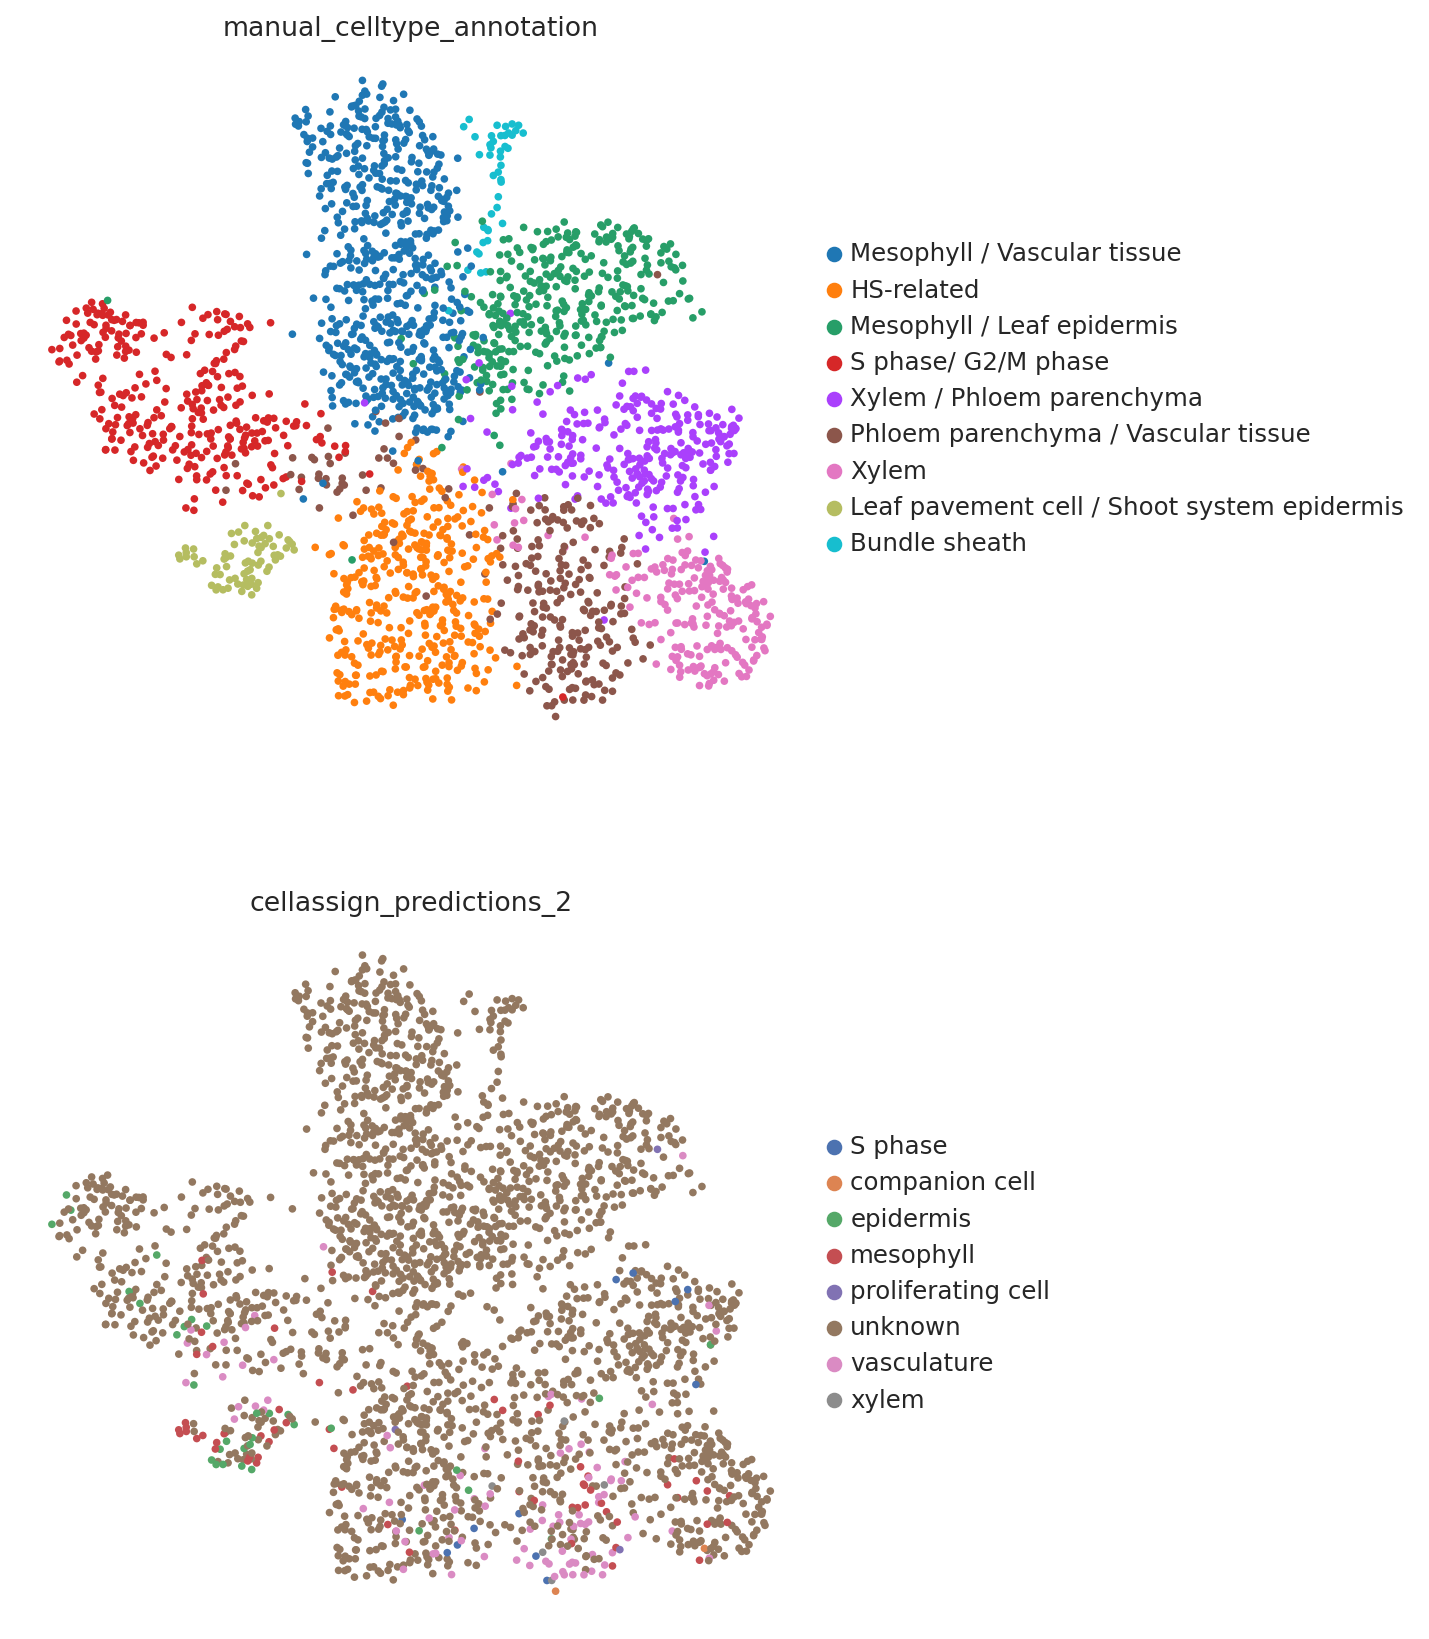

In [35]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

In [36]:
l1.write("L1_annotation.h5ad")
l2.write("L2_annotation.h5ad")

In [15]:
l1 = sc.read('L1_norm.h5ad')
l2 = sc.read('L1_norm.h5ad')


In [5]:
cell_cycle_genes = pd.read_csv('/home/sources/atlases/regress_out.tsv', sep='\t')

In [6]:
cell_cycle_genes

,Gene,Description,Process,Reference
0,AT2G26390,putative serpin,protoplasting,https://doi.org/10.1038/nmeth0805-615
1,AT2G26400,unknown protein similar to GP|2244827|gnl|PID|...,protoplasting,https://doi.org/10.1038/nmeth0805-616
2,AT2G26530,"AR781, similar to yeast pheromone receptor ide...",protoplasting,https://doi.org/10.1038/nmeth0805-617
3,AT2G41640,unknown protein ; supported by cDNA: gi_169304...,protoplasting,https://doi.org/10.1038/nmeth0805-618
4,AT2G47550,putative pectinesterase ;supported by full-len...,protoplasting,https://doi.org/10.1038/nmeth0805-619
...,...,...,...,...
377,AT5G17020,XPO1A,S phase,https://doi.org/10.1111/ppl.14524
378,AT3G55570,CTU1,S phase,https://doi.org/10.1111/ppl.14525
379,AT2G27970,CKS2,S phase,https://doi.org/10.1111/ppl.14526
380,AT2G46600,KIC,S phase,https://doi.org/10.1111/ppl.14527


In [16]:
s_genes = cell_cycle_genes[cell_cycle_genes['Process']=='S phase']['Gene']
g2m_genes = cell_cycle_genes[cell_cycle_genes['Process']=='G2/M phase']['Gene']
cell_cycle_genes_l1 = [x for x in cell_cycle_genes['Gene'] if x in l1.var_names]
cell_cycle_genes_l2 = [x for x in cell_cycle_genes['Gene'] if x in l2.var_names]

In [17]:
cell_cycle_genes_l1

['AT1G02970',
 'AT3G24810',
 'AT5G22220',
 'AT1G47210',
 'AT1G20930',
 'AT5G11300',
 'AT3G11520',
 'AT4G35620',
 'AT1G08560',
 'AT4G22910',
 'AT4G32830',
 'AT2G18290',
 'AT2G20000',
 'AT1G78770',
 'AT1G20930',
 'AT3G48150',
 'AT2G39090',
 'AT3G01090',
 'AT5G17020',
 'AT2G27970',
 'AT2G46600']

       'AT2G17620', 'AT1G76310', 'AT1G16330', 'AT4G33270', 'AT2G45490',
       'AT2G04660'],
      dtype='object')


/opt/conda/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


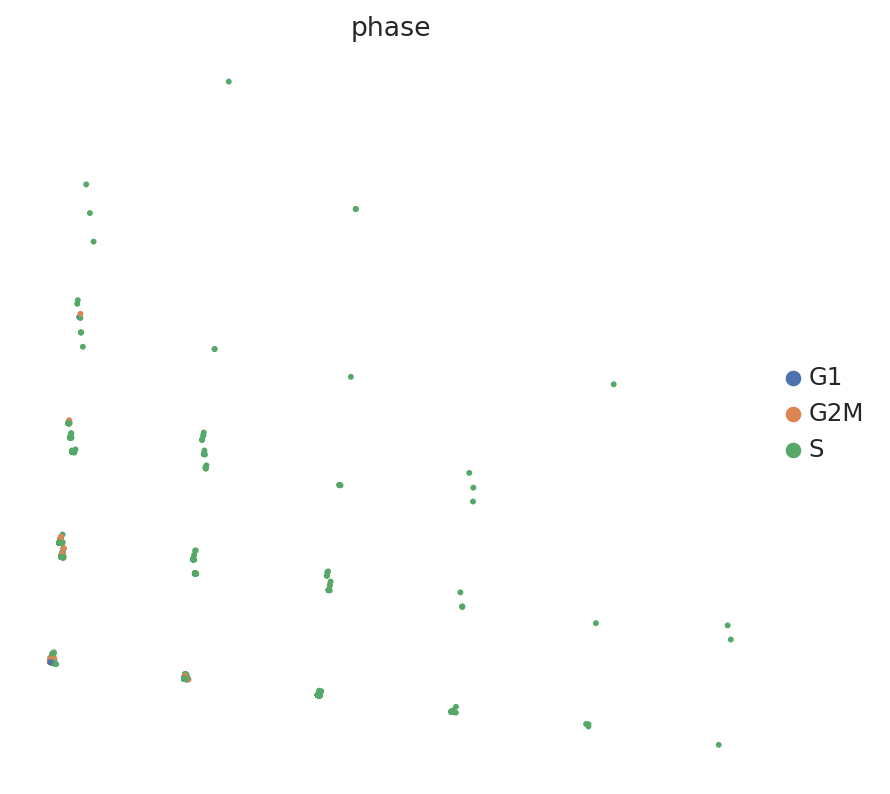

In [18]:
sc.tl.score_genes_cell_cycle(l1, s_genes=s_genes, g2m_genes=g2m_genes)
l1_cc_genes = l1[:, cell_cycle_genes_l1]
sc.tl.pca(l1_cc_genes)
sc.pl.pca_scatter(l1_cc_genes, color='phase')